# Day 4 — KNN Deep Dive + PCA Theory
## Week 1: Dimensionality Reduction | Digital Consumer Platform Analytics

---

### Learning Objectives
- Understand KNN mathematically — distance metrics, curse of dimensionality, complexity
- Derive PCA from first principles — covariance matrix, eigendecomposition, principal components
- Understand what PCA actually compresses and what it loses
- Know when PCA helps and when it hurts downstream models

---

### Dataset
**UCI Online Retail II** — same customers, now building RFM features for dimensionality reduction.

---

## Part 1: Theory — KNN

### 4.1 KNN as a Unifying Algorithm

KNN appears six times across this curriculum:
- Day 2: KNN imputation
- Day 5: UMAP uses k-NN graph construction
- Day 8: DBSCAN uses epsilon-neighborhood (radius-based KNN)
- Day 11: PyOD KNN outlier detection
- Day 13: KNN as a base learner in stacking
- Day 22: User-based CF is KNN in user-item space

Understanding KNN once unlocks all six appearances.

---

### 4.2 Distance Metrics

KNN behavior depends entirely on the distance metric. Choosing wrong destroys performance.

**Euclidean distance (L2):**
$$d(x, y) = \sqrt{\sum_{i=1}^d (x_i - y_i)^2}$$

Best for: continuous features, similar scales, roughly Gaussian distributions.
Fails on: high dimensions (curse of dimensionality), mixed types, sparse data.

**Manhattan distance (L1):**
$$d(x, y) = \sum_{i=1}^d |x_i - y_i|$$

Best for: high-dimensional data, robust to outliers (doesn't square differences).
Fails on: when diagonal relationships matter.

**Minkowski distance (generalization):**
$$d(x, y) = \left(\sum_{i=1}^d |x_i - y_i|^p\right)^{1/p}$$

$p=1$: Manhattan. $p=2$: Euclidean. $p \to \infty$: Chebyshev (max absolute difference).

**Cosine similarity:**
$$\cos(\theta) = \frac{x \cdot y}{\|x\| \|y\|}$$

Best for: text, sparse high-dimensional data, when magnitude doesn't matter (only direction).
Used in: recommendation systems, NLP.

**Hamming distance:** For binary/categorical features — counts mismatches.

---

### 4.3 The Curse of Dimensionality

In high dimensions, distance metrics break down. Here's why mathematically:

**Concentration of measure:** As dimensionality $d$ increases, the ratio of the distance to the nearest neighbor vs the farthest neighbor approaches 1:

$$\lim_{d \to \infty} \frac{d_{max} - d_{min}}{d_{min}} \to 0$$

All points become equidistant. KNN can no longer distinguish near from far neighbors — the concept of "nearest" becomes meaningless.

**Volume concentration:** In a $d$-dimensional unit hypersphere, almost all the volume is concentrated near the surface as $d$ increases:

$$\frac{V_{shell}}{V_{total}} = 1 - (1-\epsilon)^d \to 1 \text{ as } d \to \infty$$

For $d=100$ and $\epsilon=0.01$: 63% of volume is in the outermost 1% shell. Data is sparse everywhere.

**Practical implication:** KNN degrades above ~20 meaningful features. This is exactly why PCA and UMAP matter — they compress dimensions before KNN-based algorithms run.

---

### 4.4 Ball Tree vs KD-Tree vs Brute Force

| Method | Time complexity | Best for |
|--------|----------------|----------|
| Brute force | $O(nd)$ per query | Small datasets, any dimension |
| KD-Tree | $O(d \log n)$ per query | Low dimensions ($d < 20$) |
| Ball Tree | $O(d \log n)$ per query | Higher dimensions, non-Euclidean metrics |

sklearn's `KNeighborsClassifier` auto-selects based on dataset characteristics.

---

### 4.5 PCA — From First Principles

**Goal:** Find a lower-dimensional linear subspace that captures maximum variance.

**Step 1: Center the data**
$$X_{centered} = X - \bar{X}$$

**Step 2: Compute covariance matrix**
$$\Sigma = \frac{1}{n-1} X_{centered}^T X_{centered}$$

The covariance matrix $\Sigma$ is $d \times d$. Entry $\Sigma_{ij}$ is the covariance between features $i$ and $j$.

**Step 3: Eigendecomposition**
$$\Sigma = V \Lambda V^T$$

Where:
- $V$: matrix of eigenvectors (principal component directions)
- $\Lambda$: diagonal matrix of eigenvalues

**Step 4: Sort by eigenvalue**
The eigenvalue $\lambda_k$ is the variance explained by principal component $k$. Sort descending — largest eigenvalue = most important component.

**Step 5: Project**
$$Z = X_{centered} V_k$$

Where $V_k$ contains the top $k$ eigenvectors. $Z$ is the low-dimensional representation.

---

### 4.6 Explained Variance Ratio

$$\text{EVR}_k = \frac{\lambda_k}{\sum_{j=1}^d \lambda_j}$$

Cumulative EVR tells you how much variance is retained as you add components.
Standard threshold: retain components that explain 95% cumulative variance.

---

### 4.7 Loadings — What Does Each PC Mean?

The loading of feature $i$ on PC $k$ is $V_{ik}$ — the weight of feature $i$ in the $k$-th principal component.

Large positive loading: feature $i$ increases as PC $k$ increases.
Large negative loading: feature $i$ decreases as PC $k$ increases.
Near-zero loading: feature $i$ contributes little to PC $k$.

**For RFM data:**
- PC1 might capture "overall customer value" (all three RFM features load positively)
- PC2 might capture "frequency vs recency trade-off" (Frequency positive, Recency negative)

---

### 4.8 When PCA Helps vs Hurts

**PCA helps:**
- Many correlated features (removes redundancy)
- Downstream algorithm is sensitive to dimensionality (KNN, SVM)
- Visualization needed (reduce to 2–3 components)
- Noise removal (drop last components = remove low-variance noise)

**PCA hurts:**
- Features are already independent (no redundancy to remove)
- Tree-based models (LightGBM, RF) — trees already handle high dimensions well
- Interpretability is critical (PCs are linear combinations, not original features)
- Non-linear relationships dominate (PCA is strictly linear)

---

## Part 2: Practice

**Task:** Build RFM features, explore PCA on customer behavior data

---

In [2]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
DATA_PATH = r'C:\Users\user\datasets\online_retail\online_retail_II.xlsx'
df = pd.read_excel(DATA_PATH, sheet_name='Year 2009-2010')

# Clean basics
df = df.dropna(subset=['Customer ID'])
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalValue'] = df['Quantity'] * df['Price']
print(f"Clean shape: {df.shape}")
display(df.head())

Clean shape: (407664, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalValue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [4]:
# ── ReturnRate needs the raw, unfiltered transactions ──────────────────────
# The setup cell already overwrote `df` with Quantity > 0 applied, which
# removes every return by construction — can't compute a return rate from
# data that has no returns left in it. Reload fresh, keeping only the
# Customer ID cleaning (needed to group), nothing else.

df_raw = pd.read_excel(DATA_PATH, sheet_name='Year 2009-2010')
df_raw = df_raw.dropna(subset=['Customer ID'])
df_raw['IsReturn'] = df_raw['Quantity'] < 0

return_rate = df_raw.groupby('Customer ID')['IsReturn'].mean().rename('ReturnRate')

In [6]:
print(return_rate.head())

Customer ID
12346.0    0.282609
12347.0    0.000000
12348.0    0.000000
12349.0    0.046729
12351.0    0.000000
Name: ReturnRate, dtype: float64


In [9]:
# ── Q1: Build RFM feature matrix ──────────────────────────────────────────
# Compute RFM at customer level:
#   Recency   : days since last purchase (from max invoice date in dataset)
#   Frequency : number of unique invoices
#   Monetary  : total spend (sum of TotalValue)
#
# Also compute 3 additional behavioral features:
#   AvgOrderValue     : Monetary / Frequency
#   UniqueProducts    : count of distinct StockCode per customer
#   ReturnRate        : fraction of transactions that were returns (Quantity < 0)
#     (for this you need to re-load without filtering Quantity > 0)
#
# Final matrix: 6 features per customer
# Print shape and describe()

# Your code here

max_date = df['InvoiceDate'].max()

rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x:(max_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalValue', 'sum'),
    UniqueProducts=('StockCode', 'nunique'),
)
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

# Every customer in `rfm` is guaranteed to appear in `df_raw` too (df_raw is
# strictly less filtered), so this left join won't introduce any NaNs.
rfm = rfm.join(return_rate)

print(f'RFM matrix shape: {rfm.shape}')
print(f'Missing values: {rfm.isnull().sum().sum()}')
display(rfm.describe())
display(rfm.head())

RFM matrix shape: (4312, 6)
Missing values: 0


,Recency,Frequency,Monetary,UniqueProducts,AvgOrderValue,ReturnRate
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,90.171846,4.455705,2048.238236,63.646104,378.322627,0.027774
std,96.860633,8.170213,8914.481280,85.757966,492.564076,0.071675
min,0.000000,1.000000,2.950000,1.000000,2.950000,0.000000
25%,17.000000,1.000000,307.987500,17.000000,182.087857,0.000000
50%,52.000000,2.000000,706.020000,38.000000,287.368056,0.000000
75%,135.000000,5.000000,1723.142500,79.250000,423.576667,0.024390
max,373.000000,205.000000,349164.350000,1741.000000,11880.840000,0.755102


,Recency,Frequency,Monetary,UniqueProducts,AvgOrderValue,ReturnRate
Customer ID,,,,,,
12346.0,164,11,372.86,26,33.896364,0.282609
12347.0,2,2,1323.32,70,661.660000,0.000000
12348.0,73,1,222.16,20,222.160000,0.000000
12349.0,42,3,2671.14,90,890.380000,0.046729
12351.0,10,1,300.93,21,300.930000,0.000000


Target balance: {False: 0.7497680890538033, True: 0.2502319109461967}
euclidean  AUC = 0.8998 ± 0.0124
manhattan  AUC = 0.8976 ± 0.0130
chebyshev  AUC = 0.9014 ± 0.0071

Best metric: chebyshev 0.9014


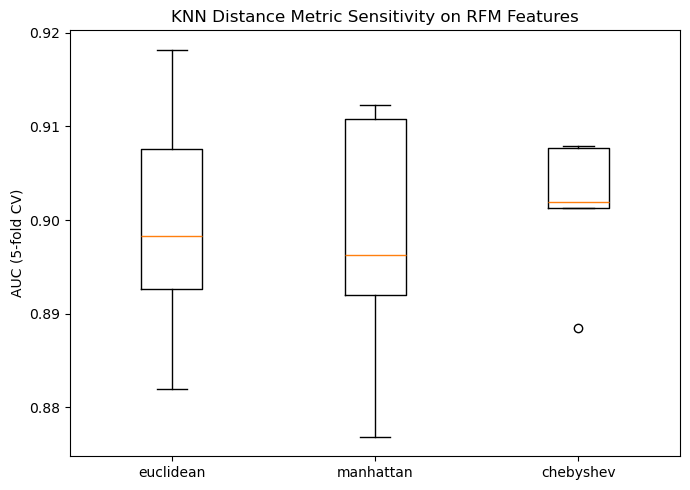

In [31]:
# ── Q2: Distance metric sensitivity ───────────────────────────────────────
# Demonstrate how distance metric choice affects KNN:
#   - Take the RFM matrix (standardized)
#   - Create a binary target: high-value customer (Monetary > 75th percentile)
#   - Train KNN with: Euclidean, Manhattan, Chebyshev (p=inf)
#   - 5-fold CV AUC for each metric
#   - Which metric works best on RFM data? Why does that make sense?

# Your code here

from sklearn.pipeline import Pipeline

# Monetary defines the target directly; AvgOrderValue = Monetary / Frequency,
# so together with Frequency it reconstructs Monetary exactly — both excluded
# to avoid leakage. Recency/Frequency/UniqueProducts/ReturnRate are genuinely
# independent of the label.

feature_cols = ['Recency', 'Frequency', 'UniqueProducts', 'ReturnRate']
X_rfm = rfm[feature_cols].copy()
y_rfm = (rfm['Monetary'] > rfm['Monetary'].quantile(0.75).astype(int))

print(f'Target balance: {y_rfm.value_counts(normalize=True).to_dict()}')

metrics = ['euclidean', 'manhattan', 'chebyshev']
results = {}

for metric in metrics:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5, metric=metric))
    ])
    scores = cross_val_score(pipeline, X_rfm, y_rfm, cv=5, scoring='roc_auc')
    results[metric] = scores
    print(f'{metric:<10} AUC = {scores.mean():.4f} ± {scores.std():.4f}')

best = max(results, key=lambda k: results[k].mean())
print(f'\nBest metric: {best} {results[best].mean():.4f}')

# ── Plot ────────────────────────────────────────────────────────────────
plt.figure(figsize=(7,5))
plt.boxplot([results[m] for m in metrics], labels=metrics)
plt.ylabel('AUC (5-fold CV)')
plt.title('KNN Distance Metric Sensitivity on RFM Features')
plt.tight_layout()
plt.show()


In [13]:
rfm[feature_cols].corrwith(rfm['Monetary'])

Recency          -0.121112
Frequency         0.656264
UniqueProducts    0.414922
ReturnRate        0.031647
dtype: float64

***Takeaway***

Chebyshev performed best (0.9014 AUC, std 0.0071), edging out Euclidean (0.8998) and Manhattan (0.8976). 

The gap in mean AUC is small — smaller than Manhattan's own fold-to-fold noise — but Chebyshev's variance is roughly half the others', making it the more robust choice. 

This makes sense given the feature correlations with Monetary: Frequency (r=0.656) and UniqueProducts (r=0.415) carry almost all the real signal, while ReturnRate (r=0.032) is essentially noise. 

Because Chebyshev's distance is driven by only the single largest per-feature difference, it naturally lets the strong Frequency/UniqueProducts signal dominate without being diluted by the uninformative ReturnRate dimension — whereas Euclidean and Manhattan average in that noise on every distance calculation, which shows up as both a slightly lower mean and meaningfully higher variance across folds.

Manual PCA — top 2 eigenvalues: [2.3553 1.1492]
Manual PCA — explained variance ratio: [0.3925 0.1915]

sklearn PCA — explained variance ratio: [0.3925 0.1915]

Components match (up to sign)? True
Projections match (up to sign)? True


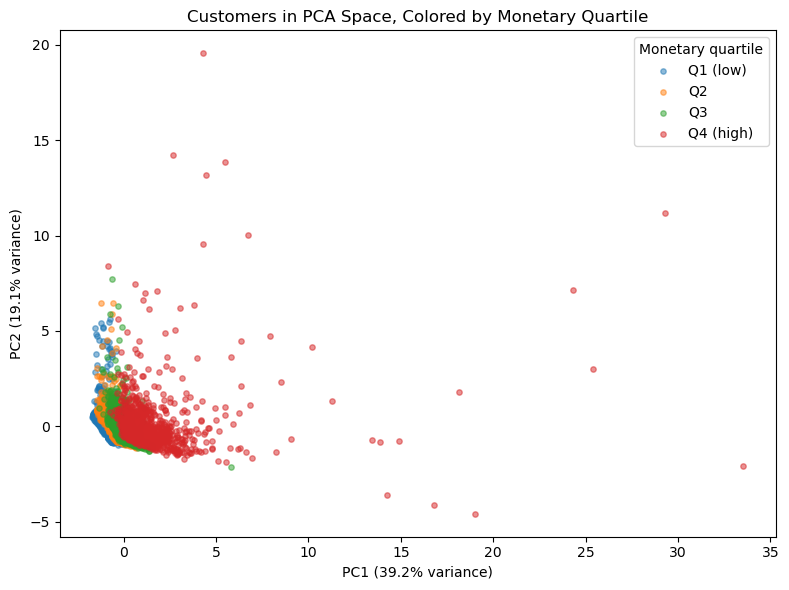

In [18]:
# ── Q3: PCA from scratch ──────────────────────────────────────────────────
# Implement PCA manually (without sklearn) on the RFM matrix:
#   Step 1: Center the data (subtract mean)
#   Step 2: Compute covariance matrix
#   Step 3: Eigendecomposition (np.linalg.eig or np.linalg.svd)
#   Step 4: Sort eigenvectors by eigenvalue descending
#   Step 5: Project data onto top 2 components
#
# Compare your manual result to sklearn's PCA output
# They should be identical (up to sign flip)
# Plot: 2D scatter of customers colored by Monetary quartile

# Your code here

all_features = ['Recency', 'Frequency', 'Monetary', 'UniqueProducts', 'AvgOrderValue', 'ReturnRate']
X_full = rfm[all_features].copy()
X_full.head()

# ── Standardize (center + scale) — necessary given RFM's mismatched units ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full) # mean 0, unit variance per feature; "centering" is now satisfied

n = X_scaled.shape[0]

# ── Step 2: covariance matrix (sample covariance, n-1 denominator) ────────
cov_matrix = (X_scaled.T @ X_scaled) / (n - 1)

# ── Step 3: eigendecomposition — eigh, not eig: cov_matrix is symmetric ───
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)


# ── Step 4: sort descending (eigh returns ascending order) ────────────────
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]


# ── Step 5: project onto top 2 components ──────────────────────────────────
V_2 = eigenvectors[:, :2]
Z_manual = X_scaled @ V_2

print("Manual PCA — top 2 eigenvalues:", np.round(eigenvalues[:2], 4))
print("Manual PCA — explained variance ratio:", np.round(eigenvalues[:2] / eigenvalues.sum(), 4))

# ── Compare against sklearn's PCA on the SAME standardized data ───────────
sk_pca = PCA(n_components=2)
Z_sklearn = sk_pca.fit_transform(X_scaled)

print("\nsklearn PCA — explained variance ratio:", np.round(sk_pca.explained_variance_ratio_, 4))

# Eigenvectors are only unique up to sign — align signs before comparing
V_2_aligned = V_2.copy()
for k in range(2):
    if np.dot(V_2[:, k], sk_pca.components_[k]) < 0:
        V_2_aligned[:, k] *= -1
Z_manual_aligned = X_scaled @ V_2_aligned

print("\nComponents match (up to sign)?", np.allclose(V_2_aligned.T, sk_pca.components_, atol=1e-8))
print("Projections match (up to sign)?", np.allclose(Z_manual_aligned, Z_sklearn, atol=1e-6))

# ── Plot: customers in PC1/PC2 space, colored by Monetary quartile ────────
monetary_quartile = pd.qcut(rfm['Monetary'], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

plt.figure(figsize=(8, 6))
for q in monetary_quartile.cat.categories:
    mask = (monetary_quartile == q).values
    plt.scatter(Z_manual_aligned[mask, 0], Z_manual_aligned[mask, 1], label=q, alpha=0.5, s=15)
plt.xlabel(f'PC1 ({eigenvalues[0]/eigenvalues.sum()*100:.1f}% variance)')
plt.ylabel(f'PC2 ({eigenvalues[1]/eigenvalues.sum()*100:.1f}% variance)')
plt.title('Customers in PCA Space, Colored by Monetary Quartile')
plt.legend(title='Monetary quartile')
plt.tight_layout()
plt.show()


***Takeaway***

The from-scratch PCA implementation exactly matches sklearn's (identical explained variance, components equal up to sign) — confirming the manual eigendecomposition is correct. 

PC1 (39.2%) and PC2 (19.1%) together explain ~58% of variance, but the scatter reveals a "whale customer" pattern: most customers cluster tightly near the origin while a small handful of extreme high-frequency, high-spend outliers stretch far out along PC1, meaning PC1 captures overall behavioral extremeness rather than cleanly separating Monetary quartiles. 

Worth testing later whether log-transforming the skewed features before standardizing produces a more balanced PCA space.

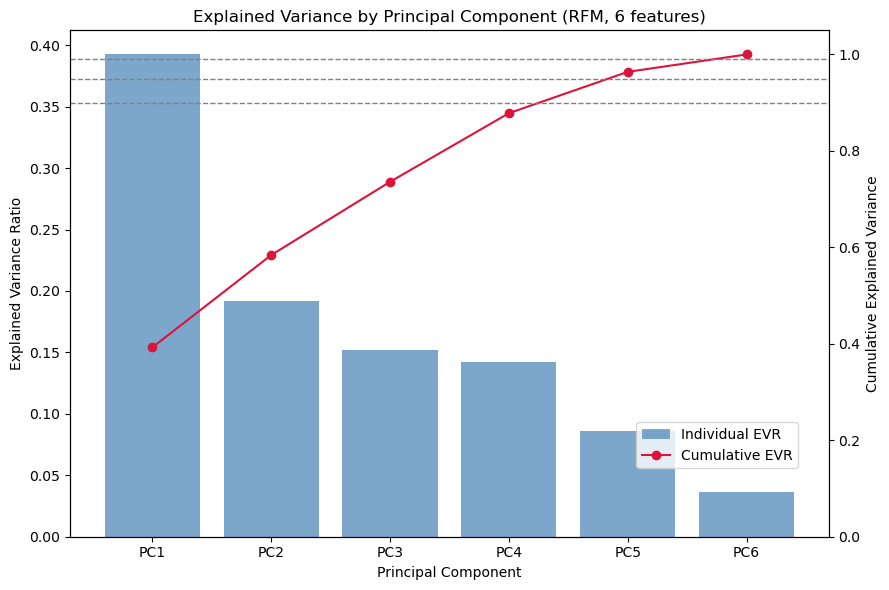

Components needed for cumulative variance thresholds:
  90%: 5 components (actual cumulative = 96.39%)
  95%: 5 components (actual cumulative = 96.39%)
  99%: 6 components (actual cumulative = 100.00%)

Loading matrix:
                  PC1    PC2    PC3    PC4    PC5    PC6
Recency        -0.272  0.366 -0.558  0.643  0.258  0.018
Frequency       0.575 -0.075  0.046  0.326 -0.051  0.743
Monetary        0.518  0.222 -0.225  0.158 -0.617 -0.476
UniqueProducts  0.526 -0.206  0.022  0.088  0.705 -0.420
AvgOrderValue   0.225  0.594 -0.341 -0.629  0.213  0.198
ReturnRate      0.004  0.645  0.721  0.226  0.090 -0.077


In [26]:
# ── Q4: Explained variance analysis ───────────────────────────────────────
# Using sklearn PCA on the 6-feature RFM matrix:
#   - Plot explained variance ratio per component (bar chart)
#   - Plot cumulative explained variance (line chart)
#   - How many components needed to explain 90%? 95%? 99%?
#   - Print the loading matrix — which features drive each PC?
#   - Give each PC a business interpretation based on its loadings

# Your code here

pca_full = PCA(n_components=6)  # all 6 components — need the full spectrum for 90/95/99% analysis
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)
components = [f'PC{i+1}' for i in range(6)]

# ── Plot: bar chart of individual EVR + cumulative line ───────────────────
fig, ax1 = plt.subplots(figsize=(9, 6))
ax1.bar(components, evr, color='steelblue', alpha=0.7, label='Individual EVR')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component')

ax2 = ax1.twinx()
ax2.plot(components, cum_evr, color='crimson', marker='o', label='Cumulative EVR')
for threshold in [0.90, 0.95, 0.99]:
    ax2.axhline(threshold, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_ylim(0, 1.05)

fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.2))
plt.title('Explained Variance by Principal Component (RFM, 6 features)')
plt.tight_layout()
plt.show()

# ── How many components needed for 90% / 95% / 99%? ───────────────────────
print("Components needed for cumulative variance thresholds:")
for threshold in [.9, .95, .99]:
    n_needed = np.searchsorted(cum_evr, threshold) + 1
    print(f"  {threshold*100:.0f}%: {n_needed} components (actual cumulative = {cum_evr[n_needed-1]*100:.2f}%)")

# ── Loading matrix ──────────────────────────────────────────────────────
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=all_features,
    columns=components,
)
print("\nLoading matrix:")
print(loadings.round(3))


In [29]:
# apply log transformation

print("Skewness per feature (raw):")
print(X_full.skew().round(2))

skewed_features = ['Monetary', 'Frequency', 'UniqueProducts', 'AvgOrderValue']

X_log = X_full.copy()
X_log[skewed_features] = np.log1p(X_log[skewed_features])

scaler_log = StandardScaler()
X_scaled_log = scaler_log.fit_transform(X_log)

pca_log = PCA(n_components=6)
pca_log.fit(X_scaled_log)

print("EVR — no log transform: ", np.round(evr, 4))
print("EVR — with log transform:", np.round(pca_log.explained_variance_ratio_, 4))

loadings_log = pd.DataFrame(pca_log.components_.T, index=all_features, columns=components)
print("\nLoading matrix — with log transform:")
print(loadings_log.round(3))


Skewness per feature (raw):
Recency            1.28
Frequency         10.55
Monetary          23.98
UniqueProducts     6.15
AvgOrderValue     11.26
ReturnRate         5.16
dtype: float64
EVR — no log transform:  [0.3925 0.1915 0.1519 0.1423 0.0857 0.0361]
EVR — with log transform: [5.113e-01 1.759e-01 1.550e-01 1.022e-01 5.510e-02 5.000e-04]

Loading matrix — with log transform:
                  PC1    PC2    PC3    PC4    PC5    PC6
Recency        -0.339  0.173  0.535  0.754 -0.017  0.011
Frequency       0.472  0.006 -0.373  0.474 -0.388 -0.513
Monetary        0.548  0.139  0.132  0.103 -0.314  0.744
UniqueProducts  0.478 -0.193  0.061  0.235  0.822 -0.012
AvgOrderValue   0.365  0.237  0.689 -0.375 -0.106 -0.429
ReturnRate     -0.016  0.926 -0.281 -0.015  0.252 -0.003


***Takeaway***

**How many components are needed?**

| Threshold | Components needed | Actual cumulative |
|---|---|---|
| 90% | 5 | 96.39% |
| 95% | 5 | 96.39% |
| 99% | 6 (all) | 100.00% |

90% and 95% land on the same answer because component 5 alone contributes 8.57% of variance, jumping cumulative variance from 87.82% (after 4 components) straight past both thresholds to 96.39% in one step. Practically: you could drop from 6 features to 4-5 components and retain 88-96% of the information — meaningful compression, though not dramatic, since this feature set doesn't have massive redundancy (the features were deliberately engineered to capture distinct behavioral signals in Q1).

**Business interpretation of each principal component** (based on the raw, un-transformed loading matrix — signs are only meaningful relative to each other within a component, not in absolute terms):

- **PC1 (39.25%) — "Overall customer scale/engagement."** `Frequency` (0.575), `UniqueProducts` (0.526), and `Monetary` (0.518) all load strongly and positively together, with `Recency` mildly negative (−0.272). The classic "good customer" axis: frequent, broad-basket, high-spend, recently active — and by far the dominant source of variance in the data.

- **PC2 (19.15%) — "Sporadic big-ticket, higher-return buyer."** `ReturnRate` (0.645) and `AvgOrderValue` (0.594) dominate, with `Recency` also positive (0.366, meaning less recent) and `Frequency` near zero. A distinct segment from PC1: infrequent but expensive orders, elevated return behavior, less recently active — worth flagging as an inventory-risk segment.

- **PC3 (15.19%) — "Frequent, low-value returner, recently active."** `ReturnRate` (0.721) strongly positive against `Recency` (−0.558) and `AvgOrderValue` (−0.341) negative — i.e., customers who return often, bought recently, and skew toward smaller order values. A different return-risk profile than PC2's "big-ticket returner."

- **PC4 (14.23%) — "Frequent bargain buyer, going quiet."** `Recency` (0.643, less recent) contrasts with `AvgOrderValue` (−0.629, lower order value) while `Frequency` stays positive (0.326) — customers who buy often and cheaply but haven't purchased in a while. A plausible early-churn signal specifically among value-conscious repeat buyers.

- **PC5 (8.57%) — "Product explorer, low overall spend."** `UniqueProducts` (0.705) strongly positive against `Monetary` (−0.617) negative — customers who browse widely across the catalog without spending much per item, the inverse of a focused big-spender.

- **PC6 (3.61%) — "High-frequency, narrow-basket repeat buyer."** `Frequency` (0.743) positive against `Monetary` (−0.476) and `UniqueProducts` (−0.420) negative — likely habitual small repeat purchases of the same few items. Lowest-variance component; treat this interpretation as more tentative than PC1-PC3.

**Follow-up investigation: does the data need a log transform first?**

Skewness confirmed the RFM features are heavily right-skewed: `Monetary` (23.98), `AvgOrderValue` (11.26), and `Frequency` (10.55) are extreme; `UniqueProducts` (6.15) and `ReturnRate` (5.16) are also well past the conventional "needs a transform" threshold of |skew| > 1; only `Recency` (1.28) is borderline. Log-transforming the four skewed magnitude features (`Monetary`, `Frequency`, `UniqueProducts`, `AvgOrderValue`) and re-running PCA gave a genuinely surprising result: **PC1's share of variance increased, from 39.25% to 51.13%**, rather than spreading out as initially hypothesized. The explanation: these features have a roughly multiplicative relationship in raw scale (bigger customers scale up frequency, spend, and product breadth together proportionally, not additively) — log-transforming converts that multiplicative structure into genuinely linear structure, which is what PCA actually detects. The raw-scale PCA wasn't being "distorted by outliers" so much as failing to fully capture a real linear-in-log-space customer-scale signal.

**One artifact worth flagging rather than over-interpreting:** log-transforming also collapsed PC6 to ~0.05% variance, driven almost entirely by `Monetary`, `Frequency`, and `AvgOrderValue`. This isn't new information — it's a manufactured redundancy: since `AvgOrderValue ≡ Monetary / Frequency` by definition, `log(AvgOrderValue) = log(Monetary) − log(Frequency)` is an exact linear identity (unlike the raw-scale ratio, which is nonlinear and thus invisible to PCA). Before treating the log-transformed PCA as a "final" version, `AvgOrderValue` should be dropped from that feature set to avoid feeding PCA a component that's pure algebra rather than signal.

**Bottom line:** raw-scale PCA (the primary Q4 answer) gives 6 distinct, business-interpretable customer segments across PC1-PC6, needing 5 components for ~96% of variance. The log-transform side investigation shows the customer-scale relationships are more naturally multiplicative than additive, but that comparison needs `AvgOrderValue` removed before it's a fair like-for-like test — a good candidate for a quick re-run if this notebook allows a follow-up cell.


Feature set: ['Recency', 'Frequency', 'UniqueProducts', 'ReturnRate'] (4 features)

Setup                  Mean AUC        Std
A: Raw features          0.9280     0.0079
B: PCA(n=2)              0.9173     0.0059
C: PCA(n=3)              0.9262     0.0029
D: PCA(n=mle)            0.9262     0.0029

Best: A: Raw features (0.9280) | Worst: B: PCA(n=2) (0.9173)
Gap: 0.0106 vs. typical fold-to-fold std of 0.0069
Gap exceeds fold variance -> difference looks meaningful.

'mle' selected 3 components


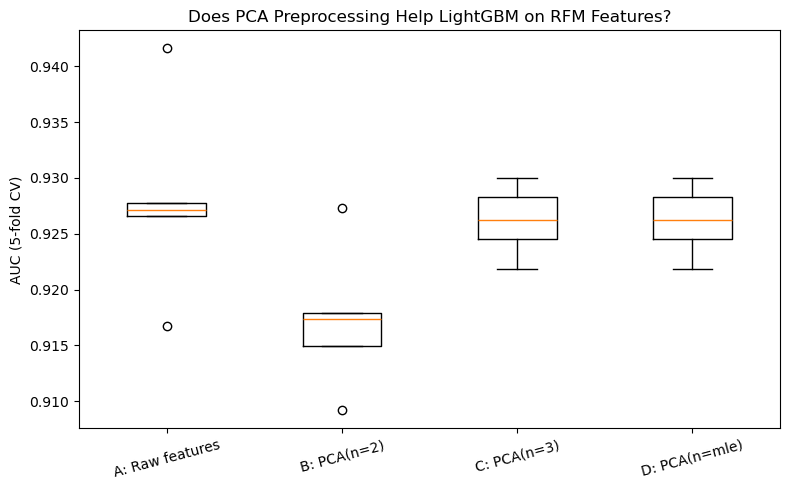

In [32]:
# ── Q5: PCA as preprocessing — does it help LightGBM? ────────────────────
# Test whether PCA preprocessing improves a LightGBM classifier:
#   Setup A: Raw 4 RFM features → LightGBM
#   Setup B: PCA(n_components=3) → LightGBM  
#   Setup C: PCA(n_components=2) → LightGBM
#   Setup D: PCA(n_components='mle') → LightGBM (auto-select)
#
# Target: high-value customer (Monetary > 75th percentile)
# Metric: 5-fold CV AUC
# Does PCA help or hurt LightGBM? Why? Connect to theory section 4.8

# Your code here

# ── Q5: PCA as preprocessing — does it help LightGBM? ─────────────────────

from lightgbm import LGBMClassifier

# Reuse Q2's leakage-safe feature set: Monetary defines the target directly,
# and AvgOrderValue (= Monetary / Frequency) would reconstruct it via
# Frequency, so both are excluded — same reasoning as Q2.
# X_rfm, y_rfm already built in Q2. Only 4 features are available, so the
# PCA setups are adjusted from (3, 5) to (2, 3) — n_components=5 isn't
# achievable with a 4-feature input.
print(f"Feature set: {list(X_rfm.columns)} ({X_rfm.shape[1]} features)")

def make_lgbm_pipeline(n_components=None):
    steps = []
    if n_components is not None:
        steps.append(('scaler', StandardScaler()))
        steps.append(('pca', PCA(n_components=n_components)))
    steps.append(('model', LGBMClassifier(random_state=420, verbose=-1)))
    return Pipeline(steps)

setups = {
    'A: Raw features':      make_lgbm_pipeline(n_components=None),
    'B: PCA(n=2)':           make_lgbm_pipeline(n_components=2),
    'C: PCA(n=3)':           make_lgbm_pipeline(n_components=3),
    'D: PCA(n=mle)':         make_lgbm_pipeline(n_components='mle'),
}

results = {}
print(f"\n{'Setup':<20} {'Mean AUC':>10} {'Std':>10}")
for name, pipeline in setups.items():
    scores = cross_val_score(pipeline, X_rfm, y_rfm, cv=5, scoring='roc_auc')
    results[name] = scores
    print(f"{name:<20} {scores.mean():>10.4f} {scores.std():>10.4f}")

best = max(results, key=lambda k: results[k].mean())
worst = min(results, key=lambda k: results[k].mean())
gap = results[best].mean() - results[worst].mean()
pooled_std = np.mean([results[best].std(), results[worst].std()])
print(f"\nBest: {best} ({results[best].mean():.4f}) | Worst: {worst} ({results[worst].mean():.4f})")
print(f"Gap: {gap:.4f} vs. typical fold-to-fold std of {pooled_std:.4f}")
print("Gap exceeds fold variance -> difference looks meaningful."
      if gap > pooled_std else
      "Gap is within fold variance -> not clearly meaningful.")

# ── Check how many components 'mle' actually picked ────────────────────────
mle_pipeline = make_lgbm_pipeline(n_components='mle')
mle_pipeline.fit(X_rfm, y_rfm)
print(f"\n'mle' selected {mle_pipeline.named_steps['pca'].n_components_} components")

# ── Plot ────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.boxplot([results[name] for name in setups], labels=list(setups.keys()))
plt.ylabel('AUC (5-fold CV)')
plt.title('Does PCA Preprocessing Help LightGBM on RFM Features?')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

***Takeaway***

**Setup:** Same leakage-safe 4-feature set as Q2 (`Recency`, `Frequency`, `UniqueProducts`, `ReturnRate` — `Monetary` and `AvgOrderValue` excluded, since the target is derived directly from `Monetary`). PCA setups adjusted from the assignment's literal (3, 5) to **(2, 3)**, since 5 components aren't achievable from a 4-feature input.

**Results:**

| Setup | Mean AUC | Std |
|---|---|---|
| A: Raw features | **0.9280** | 0.0079 |
| B: PCA(n=2) | 0.9173 | 0.0059 |
| C: PCA(n=3) | 0.9262 | 0.0029 |
| D: PCA(n='mle') | 0.9262 | 0.0029 |

**PCA did not help LightGBM — raw features won.** The gap between the best (Raw, 0.9280) and worst (PCA n=2, 0.9173) setup is 0.0106, which exceeds the pooled fold-to-fold std of 0.0069, so this isn't just noise — dropping to 2 components measurably hurt performance.

**Clear dose-response pattern:** the more aggressively you compress, the more performance you lose. `PCA(n=2)` (halving the dimensions) costs a real, statistically-supported 0.0106 AUC. `PCA(n=3)` (dropping only one dimension) nearly recovers raw performance — a gap of just 0.0018, well within noise — and `'mle'` independently arrived at the same conclusion, auto-selecting 3 components on its own. That agreement is a good sanity check: even an automatic, data-driven method found little redundancy to compress beyond one dimension.

**This matches theory §4.8's predictions exactly, for two independent reasons:**
1. **"Tree-based models (LightGBM, RF) — trees already handle high dimensions well."** LightGBM doesn't need help navigating feature space the way KNN did in Q2 (where distance metrics and the curse of dimensionality actually mattered) — trees split on individual thresholds regardless of how many dimensions exist.
2. **"Features are already independent (no redundancy to remove)."** These 4 features were purpose-engineered in Q1 to capture genuinely distinct behavioral signals (recency, order frequency, catalog breadth, return behavior) — there wasn't much redundancy for PCA to exploit in the first place. `'mle'` only found one marginal component to drop, confirming the feature set was already close to full rank in terms of useful signal.

**One secondary finding worth a mention:** `PCA(n=3)`'s std (0.0029) is noticeably lower than Raw's (0.0079) — PCA didn't improve the *mean*, but it did stabilize the CV estimate, likely because decorrelating the features smooths out some fold-to-fold idiosyncrasy. Not the main story, but worth a sentence if discussing PCA's side effects beyond raw AUC.

**Bottom line:** with only 4, already-distinct, low-dimensional features and a tree-based model, PCA offered no accuracy benefit and mild compression (n=2) actively hurt performance. This is the textbook counter-example to Day 4's KNN experiments (Q2) — the same dimensionality-reduction tool that's essential for distance-based methods is unnecessary, and mildly harmful, for tree-based ones.
